# Beekeeper — Notebook 03: Modelo LSTM (CRNN)

**Proyecto Final IA** — Curso de Especialización en Inteligencia Artificial y Big Data — IES Azarquiel

---

## Qué hace este notebook

1. Carga el `mel_dataset.npz` generado en el notebook 02.
2. Define un modelo **CNN + BiLSTM** (CRNN). Las capas Conv1D iniciales reducen los ~2.585 frames temporales a una secuencia tratable y el BiLSTM modela el contexto a lo largo del segmento.
3. Entrena con `class_weight` para compensar el desbalance moderado y valida con el split GroupKFold (sin leakage por grabación).
4. Evalúa: accuracy, **F1 macro** (la métrica que importa), matriz de confusión, classification report.
5. Implementa una función `predecir_audio(ruta)` que acepta un audio de **cualquier duración**, lo trocea en chunks de 60 s, predice cada chunk y devuelve:
   - La clase de cada chunk individualmente.
   - La clase agregada del audio completo (media de las probabilidades).
   - Un nivel de confianza.

## Configuración

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q librosa

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

RUTA_OUT = '/content/drive/MyDrive/beekeeper_proyecto/'
RUTA_NPZ = os.path.join(RUTA_OUT, 'mel_dataset.npz')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

QUEEN_STATUS_NOMBRES = {
    0: 'Reina original',
    1: 'Sin reina',
    2: 'Reina nueva rechazada',
    3: 'Reina nueva aceptada',
}

print('TF version:', tf.__version__)
print('GPU disponible:', bool(tf.config.list_physical_devices('GPU')))

TF version: 2.20.0
GPU disponible: False


## 1. Cargar los datos preprocesados

`X` ya está normalizado (z-score) y padeado a `T_FIXED` frames. Lo transponemos a forma `(N, T, F)` que es la que esperan las capas RNN/Conv1D de Keras: timesteps por filas, features por columnas.

In [5]:
data = np.load(RUTA_NPZ, allow_pickle=True)

X = data['X']                   # (N, n_mels, T_FIXED)
y = data['y'].astype(np.int64)  # (N,)
train_idx = data['train_idx']
val_idx = data['val_idx']
groups = data['groups']
segmentos = data['segmentos']

# Para LSTM/Conv1D: (N, timesteps, features) → cada paso temporal es un vector de n_mels valores
X = np.transpose(X, (0, 2, 1))

N, T, F = X.shape
N_CLASES = len(np.unique(y))

print(f'X shape: {X.shape}   (N, T, n_mels)')
print(f'N_CLASES = {N_CLASES}')
print(f'Train: {len(train_idx)}   Val: {len(val_idx)}')

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

X shape: (7100, 2584, 128)   (N, T, n_mels)
N_CLASES = 4
Train: 5680   Val: 1420


## 2. `class_weight` para compensar el desbalance

El EDA ya reveló que el reparto de clases no es uniforme. `compute_class_weight` da más peso a las clases minoritarias en la pérdida, lo que evita que el modelo se acomode prediciendo siempre la clase mayoritaria.

In [6]:
pesos = compute_class_weight('balanced', classes=np.arange(N_CLASES), y=y_train)
class_weight = {i: float(w) for i, w in enumerate(pesos)}
print('class_weight:', class_weight)

class_weight: {0: 1.714975845410628, 1: 1.868421052631579, 2: 1.1387329591018445, 3: 0.4991212653778559}


## 3. Modelo CRNN (Conv1D + BiLSTM)

**Por qué CRNN y no LSTM puro:** un segmento de 60 s a `hop=512` da ~2.585 timesteps. Una LSTM pura sobre 2.585 timesteps es lentísima y aprende mal. La solución estándar es usar primero unas capas Conv1D con `MaxPooling` que actúen como extractor local de features y reductor de la dimensión temporal — la BiLSTM recibe entonces ~80 timesteps con features más ricas.

Arquitectura:

- **Conv1D 64 + Pool 4** y **Conv1D 128 + Pool 4** → reducen 2.585 → ~160 frames de features locales.
- **BiLSTM 64** con `return_sequences=True` → contexto bidireccional sobre toda la secuencia.
- **BiLSTM 32** → resumen final del segmento.
- **Dense 64** → **Softmax 4**.

Es lo que en la literatura se llama un **CRNN** y es la arquitectura de referencia para clasificación de audio con secuencia.

In [7]:
def construir_modelo(t_steps: int, n_features: int, n_clases: int) -> tf.keras.Model:
    inputs = layers.Input(shape=(t_steps, n_features), name='mel_input')

    # --- Bloque convolucional: extrae features locales y baja la dimensión temporal ---
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.Dropout(0.3)(x)

    # --- Bloque recurrente: contexto temporal bidireccional ---
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=False, dropout=0.2))(x)

    # --- Cabecera de clasificación ---
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_clases, activation='softmax')(x)

    model = models.Model(inputs, out, name='crnn_beekeeper')
    return model


modelo = construir_modelo(T, F, N_CLASES)
modelo.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
modelo.summary()

Model: "crnn_beekeeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_input (InputLayer)          │ (None, 2584, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2584, 64)       │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2584, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 646, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 646, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 646, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 161, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 161, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 161, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,332 (888.02 KB)

 Trainable params: 226,948 (886.52 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Entrenamiento

In [8]:
ruta_modelo = os.path.join(RUTA_OUT, 'modelo_crnn.keras')

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    callbacks.ModelCheckpoint(ruta_modelo, monitor='val_accuracy', save_best_only=True, verbose=0),
]

historia = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    class_weight=class_weight,
    callbacks=cbs,
    verbose=1,
)
print(f'\nMejor modelo guardado en: {ruta_modelo}')

Epoch 1/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 65s 322ms/step - accuracy: 0.5831 - loss: 1.0824 - val_accuracy: 0.5056 - val_loss: 1.4222 - learning_rate: 0.0010
Epoch 2/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 54s 303ms/step - accuracy: 0.7190 - loss: 0.7745 - val_accuracy: 0.5620 - val_loss: 1.3042 - learning_rate: 0.0010
Epoch 3/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 54s 305ms/step - accuracy: 0.7636 - loss: 0.6541 - val_accuracy: 0.6972 - val_loss: 0.7251 - learning_rate: 0.0010
Epoch 4/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 54s 302ms/step - accuracy: 0.8069 - loss: 0.5579 - val_accuracy: 0.6817 - val_loss: 0.9765 - learning_rate: 0.0010
Epoch 5/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 55s 307ms/step - accuracy: 0.8218 - loss: 0.5116 - val_accuracy: 0.6810 - val_loss: 1.0762 - learning_rate: 0.0010
Epoch 6/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 54s 304ms/step - accuracy: 0.8350 - loss: 0.4690 - val_accuracy: 0.7754 - val_loss: 0.6246 - learning_rate: 0.0010
Epoch 7/40
178/178 ━━━━━━━━━━━━━━━━━━━━ 61s 345ms/step - accuracy: 0.8

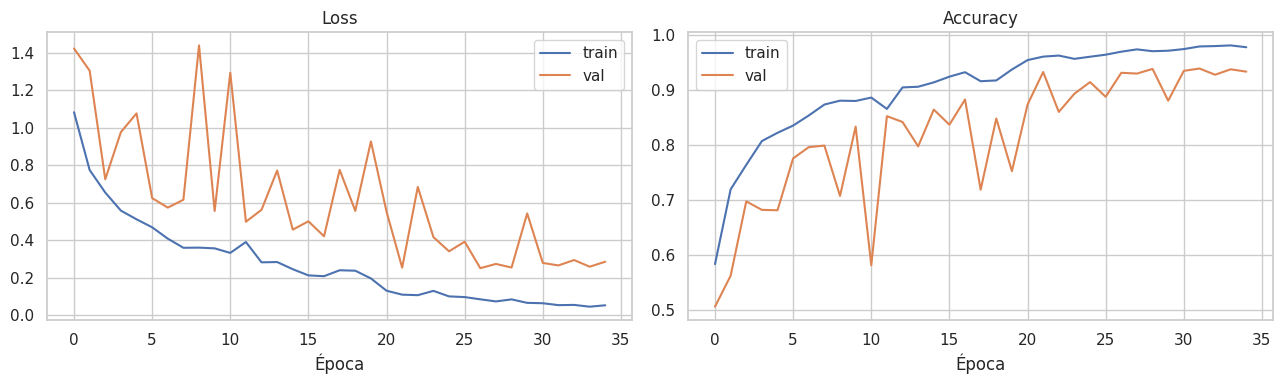

In [9]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(historia.history['loss'], label='train')
axes[0].plot(historia.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot(historia.history['accuracy'], label='train')
axes[1].plot(historia.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Evaluación

Métricas pedidas en el EDA: accuracy + **F1 macro** (insensible al desbalance) + matriz de confusión + classification report por clase.

In [10]:
y_pred_proba = modelo.predict(X_val, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)

acc = accuracy_score(y_val, y_pred)
f1_m = f1_score(y_val, y_pred, average='macro')
print(f'Accuracy: {acc:.4f}')
print(f'F1 macro: {f1_m:.4f}')
print()
print(classification_report(
    y_val, y_pred,
    target_names=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    digits=3,
))

Accuracy: 0.9310
F1 macro: 0.9133

                       precision    recall  f1-score   support

       Reina original      0.900     0.895     0.897       210
            Sin reina      0.895     0.871     0.883       186
Reina nueva rechazada      0.867     0.958     0.910       306
 Reina nueva aceptada      0.981     0.946     0.963       718

             accuracy                          0.931      1420
            macro avg      0.911     0.917     0.913      1420
         weighted avg      0.933     0.931     0.931      1420



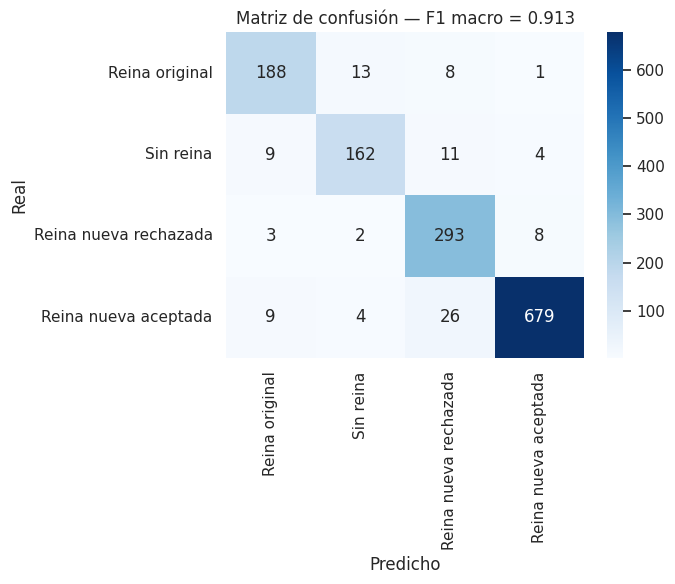

In [11]:
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    yticklabels=[QUEEN_STATUS_NOMBRES[i] for i in range(N_CLASES)],
    ax=ax,
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusión — F1 macro = {f1_m:.3f}')
plt.tight_layout()
plt.show()

---

## 6. Inferencia sobre audio de duración arbitraria

Caso de uso real: el apicultor sube un audio de **X minutos**. La función `predecir_audio` lo trocea en chunks de 60 s (idéntica longitud que los segmentos de entrenamiento), predice cada chunk y agrega los resultados.

Estrategias de agregación:

- **Promedio de probabilidades** (recomendado): suma las softmax de cada chunk y se queda con el argmax. Más robusto que voto duro porque tiene en cuenta la confianza de cada chunk.
- **Voto mayoritario**: cada chunk vota por su clase, gana la más votada. Lo devolvemos también para comparar.

Si el audio dura menos de 60 s se padea con silencio. Si dura más, se procesan **todos** los chunks completos y se descartan los segundos sobrantes (`< 60 s` finales) si no llegan a un umbral mínimo (3 s) — un chunk muy corto distorsiona la predicción.

In [12]:
# Parámetros que vienen del .npz para que el preprocesado de inferencia sea idéntico al de entrenamiento
SR_INF = int(data['sr'])
N_MELS_INF = int(data['n_mels'])
HOP_INF = int(data['hop'])
T_FIXED_INF = int(data['t_fixed'])
DURACION_CHUNK = 60.0  # s

print(f'SR={SR_INF}  n_mels={N_MELS_INF}  hop={HOP_INF}  T_FIXED={T_FIXED_INF}')

SR=22050  n_mels=128  hop=512  T_FIXED=2584


In [13]:
def _audio_chunk_a_mel(y_chunk: np.ndarray) -> np.ndarray:
    """Mismo pipeline que en preprocesamiento: Mel → dB → pad/truncate → z-score."""
    mel = librosa.feature.melspectrogram(
        y=y_chunk, sr=SR_INF, n_mels=N_MELS_INF, n_fft=2048, hop_length=HOP_INF
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    T = mel_db.shape[1]
    if T < T_FIXED_INF:
        mel_db = np.pad(mel_db, ((0, 0), (0, T_FIXED_INF - T)),
                        mode='constant', constant_values=mel_db.min())
    elif T > T_FIXED_INF:
        mel_db = mel_db[:, :T_FIXED_INF]

    mu, sigma = mel_db.mean(), mel_db.std() + 1e-6
    mel_db = (mel_db - mu) / sigma
    return mel_db.astype(np.float32)


def _trocear(y: np.ndarray, sr: int, dur_chunk_s: float = DURACION_CHUNK,
             min_resto_s: float = 3.0) -> list:
    """Devuelve una lista de arrays de audio cada uno de exactamente `dur_chunk_s`.

    El último chunk se padea con silencio si su resto supera `min_resto_s`,
    así no perdemos información de un audio de p.ej. 4:35 (4 chunks completos + 35s).
    Si el resto es menor que `min_resto_s` se descarta porque un chunk muy corto
    distorsiona la predicción."""
    n = int(dur_chunk_s * sr)
    chunks = []
    for inicio in range(0, len(y), n):
        c = y[inicio: inicio + n]
        if len(c) == n:
            chunks.append(c)
        elif len(c) >= int(min_resto_s * sr):
            # Padding con ceros para llegar a 60s
            c_pad = np.pad(c, (0, n - len(c)), mode='constant')
            chunks.append(c_pad)
        # si es más corto que `min_resto_s`, lo descartamos
    if not chunks:
        # audio total <3s: lo padeamos a 60s y devolvemos un único chunk
        c_pad = np.pad(y, (0, max(0, n - len(y))), mode='constant')
        chunks.append(c_pad[:n])
    return chunks


def predecir_audio(ruta_audio: str, modelo_keras=None, mostrar=True) -> dict:
    """
    Predice la clase de un audio de duración arbitraria.

    Returns dict con:
      - prediccion_global: int  (clase del audio completo)
      - nombre_global:     str  (nombre legible)
      - confianza_global:  float (max prob promedio)
      - probs_globales:    np.ndarray (4,) probs medias por clase
      - predicciones_chunk: list[int] (clase por chunk)
      - probs_chunk:        np.ndarray (n_chunks, 4)
      - n_chunks:           int
      - duracion_audio_s:   float
    """
    if modelo_keras is None:
        modelo_keras = modelo  # variable global

    y_audio, sr = librosa.load(ruta_audio, sr=SR_INF, mono=True)
    duracion = len(y_audio) / sr

    chunks = _trocear(y_audio, sr)
    mels = np.stack([_audio_chunk_a_mel(c) for c in chunks])  # (n, n_mels, T)
    mels = np.transpose(mels, (0, 2, 1))                       # (n, T, n_mels)

    probs = modelo_keras.predict(mels, verbose=0)              # (n, 4)
    preds_chunk = probs.argmax(axis=1)

    # Agregación: promedio de probabilidades
    probs_global = probs.mean(axis=0)
    pred_global = int(probs_global.argmax())
    conf_global = float(probs_global[pred_global])

    # Voto mayoritario (alternativo)
    voto = int(np.bincount(preds_chunk, minlength=N_CLASES).argmax())

    resultado = {
        'prediccion_global': pred_global,
        'nombre_global': QUEEN_STATUS_NOMBRES[pred_global],
        'confianza_global': conf_global,
        'voto_mayoritario': voto,
        'voto_mayoritario_nombre': QUEEN_STATUS_NOMBRES[voto],
        'probs_globales': probs_global,
        'predicciones_chunk': preds_chunk.tolist(),
        'probs_chunk': probs,
        'n_chunks': len(chunks),
        'duracion_audio_s': duracion,
    }

    if mostrar:
        print(f'Audio: {os.path.basename(ruta_audio)}')
        print(f'Duración: {duracion:.1f} s → {len(chunks)} chunks de 60 s')
        print()
        print('Predicción por chunk:')
        for i, (p, pr) in enumerate(zip(preds_chunk, probs)):
            print(f'  Chunk {i+1}: clase {p} ({QUEEN_STATUS_NOMBRES[p]})  '
                  f'— probs: {np.round(pr, 3)}')
        print()
        print(f'==> Predicción del audio completo: '
              f'{QUEEN_STATUS_NOMBRES[pred_global]} '
              f'(confianza {conf_global*100:.1f}%)')
        if voto != pred_global:
            print(f'    [Nota: voto mayoritario sería {QUEEN_STATUS_NOMBRES[voto]} — '
                  f'discrepa con el promedio de probabilidades]')
    return resultado

### Demo de inferencia

Cogemos un audio aleatorio del set de validación y lo pasamos por la función. Como cada `.wav` del dataset dura exactamente 60 s, devolverá un único chunk; la prueba útil de verdad es cuando el apicultor suba un audio de varios minutos.

In [14]:
# Demo: cogemos uno de validación
RUTA_AUDIOS = '/content/drive/MyDrive/datasets/kaggle/datasets/annajyang/beehive-sounds/versions/3/sound_files/sound_files/'

idx_demo = val_idx[0]
ruta_demo = os.path.join(RUTA_AUDIOS, str(segmentos[idx_demo]))
print(f'Etiqueta real: {QUEEN_STATUS_NOMBRES[int(y[idx_demo])]}\n')

_ = predecir_audio(ruta_demo)

Etiqueta real: Reina original

Audio: 2022-06-05--17-41-01_2__segment0.wav
Duración: 60.0 s → 1 chunks de 60 s

Predicción por chunk:
  Chunk 1: clase 0 (Reina original)  — probs: [0.919 0.006 0.074 0.001]

==> Predicción del audio completo: Reina original (confianza 91.9%)


### Concatenando varios audios para probar el caso multi-chunk

Concatenamos 5 segmentos de la misma colmena en un único `.wav` de 5 min para validar que la función trocea bien y agrega correctamente.

In [15]:
import soundfile as sf

# Coger 5 segmentos de la misma grabación
mismo_audio = pd.Series(groups[val_idx]).value_counts().idxmax()
mascara = (groups == mismo_audio)
indices_demo = np.where(mascara)[0][:5]
print(f'Concatenando {len(indices_demo)} segmentos del audio: {mismo_audio}')

ys = []
for i in indices_demo:
    yi, _ = librosa.load(os.path.join(RUTA_AUDIOS, str(segmentos[i])), sr=SR_INF, mono=True)
    ys.append(yi)
audio_largo = np.concatenate(ys)
print(f'Duración total: {len(audio_largo)/SR_INF:.1f} s')

ruta_largo = os.path.join(RUTA_OUT, 'demo_audio_largo.wav')
sf.write(ruta_largo, audio_largo, SR_INF)

print(f'Etiquetas reales por chunk: {y[indices_demo].tolist()} '
      f'({[QUEEN_STATUS_NOMBRES[v] for v in y[indices_demo]]})\n')

resultado = predecir_audio(ruta_largo)

Concatenando 5 segmentos del audio: 2022-06-05--17-41-01_2.raw
Duración total: 300.0 s
Etiquetas reales por chunk: [0, 0, 0, 0, 0] (['Reina original', 'Reina original', 'Reina original', 'Reina original', 'Reina original'])

Audio: demo_audio_largo.wav
Duración: 300.0 s → 5 chunks de 60 s

Predicción por chunk:
  Chunk 1: clase 0 (Reina original)  — probs: [0.921 0.006 0.072 0.001]
  Chunk 2: clase 0 (Reina original)  — probs: [0.999 0.    0.    0.   ]
  Chunk 3: clase 0 (Reina original)  — probs: [0.902 0.004 0.088 0.006]
  Chunk 4: clase 2 (Reina nueva rechazada)  — probs: [0.023 0.004 0.954 0.02 ]
  Chunk 5: clase 2 (Reina nueva rechazada)  — probs: [0.023 0.009 0.966 0.002]

==> Predicción del audio completo: Reina original (confianza 57.4%)


---

## 7. Recap

Lo que hace el sistema completo:

- El `.npz` del notebook 02 lleva los 7.100 espectrogramas Mel ya normalizados.
- El CRNN entrena en pocos minutos con la GPU de Colab y se valida sin leakage por colmena.
- La función `predecir_audio` deja todo encapsulado: dale un `.wav` de cualquier duración y te devuelve la predicción global + la predicción por chunk + las probabilidades.

Próximos pasos posibles:

- Cross-validation completa con los 5 folds de `folds.npz`.
- Reemplazar el CRNN por un Transformer ligero (Audio Spectrogram Transformer) si se quiere subir el F1.
- Empaquetar `predecir_audio` en una pequeña app web con Gradio o Streamlit para que el apicultor suba el audio desde el navegador.